 '80000

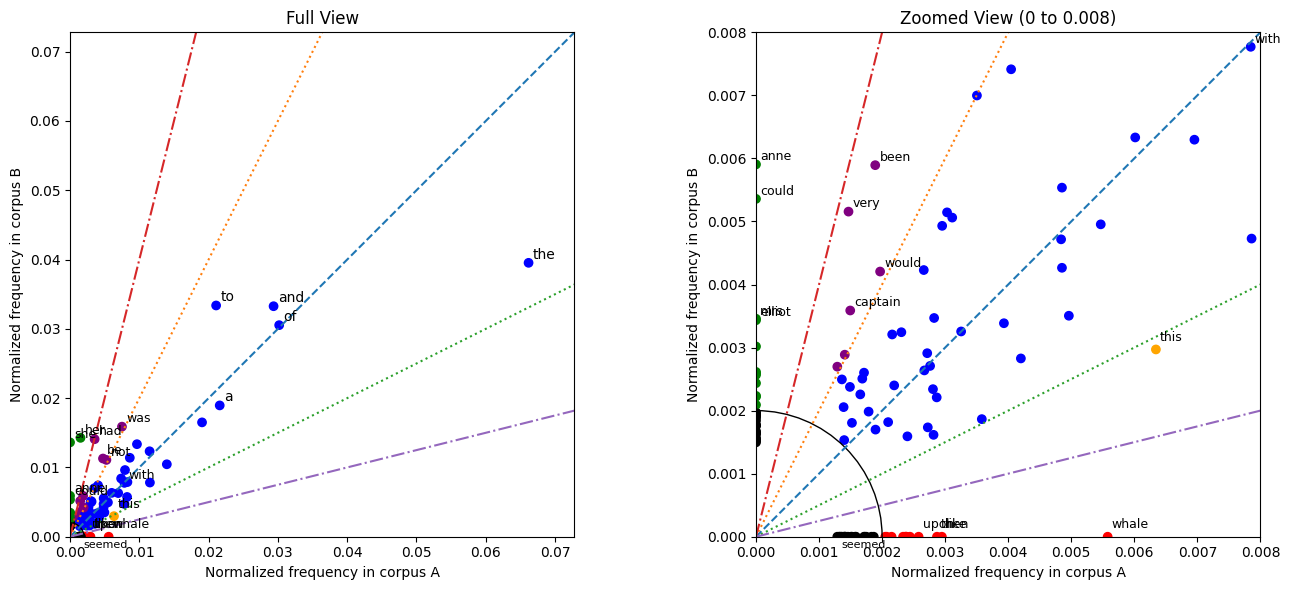

In [1]:
import node as nd 
import grapher as gr

#f1 = 'data/poe/poe_collected_works.txt'
f1 = 'data/poe/melville_moby_dick.txt'
f2 = 'data/poe/austen_persuasion.txt'
_uniquify = False

n_casko = nd.Node()
n_casko.load_file(f1, uniquify=_uniquify)

n_raven = nd.Node()
n_raven.load_file(f2, uniquify=_uniquify)

#n_raven.visualize_dual(n_casko, cutoff=100, num_labeled=6, zoom_max=0.01)
band_ratio=1.0
axis_ratio=4.0
black_hole_radius=0.02
num_labeled=4
zoom_max=0.008
n_casko.visualize_dual(n_raven,
                       band_ratio=band_ratio,
                       cutoff=100,
                       num_labeled=num_labeled,
                       zoom_max=zoom_max)

#40     def visualize_dual(self, background, num_labeled=num_labeled, cutoff=100,
#241                        band_ratio=band_ratio, axis_ratio=axis_ratio,
#242                        black_hole_radius=black_hole_radius, zoom_max=zoom_max):

In [2]:
print(f"{f1} against {f2}")
n_casko.show_top(n_raven, cutoff=10, ratio=1)

data/poe/melville_moby_dick.txt against data/poe/austen_persuasion.txt
0.0662 0.0395 the
0.0294 0.0333 and
0.0302 0.0305 of
0.0211 0.0334 to
0.0216 0.0190 a
0.0191 0.0165 in
0.0000 0.0159 was
0.0000 0.0143 her
0.0000 0.0141 had
0.0140 0.0000 that


In [7]:
import math
import node as nd

f1 = 'data/poe/melville_moby_dick.txt'
f2 = 'data/poe/austen_persuasion.txt'
_uniquify = False

n_a = nd.Node()
n_a.load_file(f1, uniquify=_uniquify)

n_b = nd.Node()
n_b.load_file(f2, uniquify=_uniquify)

x, y, words = n_a.create_xy_table(n_b, cutoff=100)

cats = nd.classify_points(
    x, y, words,
    k_diag=2.0,
    k_axis=4.0,
    black_hole_radius=0.002
)

#for xi, yi, w, c in zip(x, y, words, cats):
#    if w == "the":
#        import math
#        r = math.sqrt(xi**2 + yi**2)
#        ratio = (yi + 1e-12) / (xi + 1e-12)
#        print("THE DEBUG")
#        print(f"word={w}  region={c}  x={xi:.6f}  y={yi:.6f}  r={r:.6f}  ratio={ratio:.3f}")

buckets = {
    "diagonal": [],
    "x_axis": [],
    "y_axis": [],
    "x_wedge": [],
    "y_wedge": [],
    "black_hole": [],
}
for xi, yi, w, c in zip(x, y, words, cats):
    r = math.sqrt(xi**2 + yi**2)
    ratio = (yi + 1e-12) / (xi + 1e-12)

    if c == "black_hole":
        score = r
    elif c == "diagonal":
        score = r #(5.0 * r) - abs(math.log(ratio))
    elif c == "x_axis":
        score = xi - yi
    elif c == "y_axis":
        score = yi - xi
    elif c == "x_wedge":
        score = (xi - yi) * r
    elif c == "y_wedge":
        score = (yi - xi) * r
    else:
        score = 0.0

    buckets[c].append((score, xi, yi, w, r, ratio))

# descending for all except black hole
for region in ["diagonal", "x_axis", "y_axis", "x_wedge", "y_wedge"]:
    buckets[region].sort(reverse=True)

# ascending for black hole = bottom ten by radius
buckets["black_hole"].sort()

for region in ["diagonal", "x_axis", "y_axis", "x_wedge", "y_wedge", "black_hole"]:
    print(f"\n{region.upper()}")
    print("-" * 72)

    for score, xi, yi, w, r, ratio in buckets[region][:10]:
        print(
            f"{w:15s} "
            f"x={xi:.6f}  y={yi:.6f}  "
            f"r={r:.6f}  ratio={ratio:.3f}  score={score:.6f}"
        )

 '80000
DIAGONAL
------------------------------------------------------------------------
the             x=0.066177  y=0.039529  r=0.077084  ratio=0.597  score=0.077084
and             x=0.029377  y=0.033268  r=0.044382  ratio=1.132  score=0.044382
of              x=0.030184  y=0.030535  r=0.042936  ratio=1.012  score=0.042936
to              x=0.021084  y=0.033375  r=0.039477  ratio=1.583  score=0.039477
a               x=0.021603  y=0.018951  r=0.028737  ratio=0.877  score=0.028737
in              x=0.019052  y=0.016503  r=0.025206  ratio=0.866  score=0.025206
that            x=0.013971  y=0.010456  r=0.017450  ratio=0.748  score=0.017450
it              x=0.011483  y=0.012333  r=0.016851  ratio=1.074  score=0.016851
i               x=0.009660  y=0.013355  r=0.016482  ratio=1.382  score=0.016482
he              x=0.008626  y=0.011394  r=0.014291  ratio=1.321  score=0.014291

X_AXIS
------------------------------------------------------------------------
whale           x=0.005577  y